# BTCUSDC Order-Flow Study: Generalized Imbalance Scaling

This notebook is the first paper-style analysis notebook for the BTCUSDC adaptation.

We use Binance `BTCUSDC` data for `20260223` and work directly on raw trades.

The core object is the generalized raw-trade imbalance:

`I_T^a = sum epsilon_t q_t^a`

where:

- `T` is the rolling trade-count window,
- `epsilon_t` is the aggressor sign,
- `q_t` is trade size,
- `a` controls how strongly larger trades are weighted.

This notebook focuses on:

- clipping policy for extreme `qty`,
- imbalance distributions for several `T` and `a`,
- even-moment scaling of `I_T^a` versus `T`,
- effective log-log slopes as a function of `a`.

Design choice:

- we stay on raw trades rather than `1-second` bars,
- because the paper's object is defined on child orders / trades rather than clock-time buckets.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


In [2]:
def find_backtester_root() -> Path:
    for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (candidate / "stats").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the exchange-data-backtester project root")


def resolve_day_dir(project_root: Path, *, symbol: str, day: str) -> Path:
    candidates = [
        project_root.parent / "exchange-data-recorder" / "data" / symbol / day,
        project_root.parent / "exchange-data-recorder" / "data" / "binance" / symbol / day,
        project_root.parent / "ExchangeDataRecorder" / "data" / symbol / day,
        project_root.parent / "ExchangeDataRecorder" / "data" / "binance" / symbol / day,
        project_root / "data" / symbol / day,
        project_root / "data" / "binance" / symbol / day,
    ]
    for candidate in candidates:
        candidate = candidate.resolve()
        if (candidate / "schema.json").is_file():
            return candidate
    raise FileNotFoundError(f"Could not locate a recorder day folder for {symbol}/{day}")


PROJECT_ROOT = find_backtester_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT


PosixPath('/Users/hoangdeveloper/PycharmProjects/exchange-data-backtester')

In [3]:
from stats.io import load_day
from stats.notebook import replay_summary
from stats.tables import get_or_build_trades_table


symbol = "BTCUSDC"
day = "20260223"
day_dir = resolve_day_dir(PROJECT_ROOT, symbol=symbol, day=day)

dataset = load_day(day_dir)
trades = get_or_build_trades_table(dataset)
replay_info = replay_summary(dataset, replay_on_gap="skip-segment")

day_dir


PosixPath('/Users/hoangdeveloper/PycharmProjects/exchange-data-recorder/data/binance/BTCUSDC/20260223')

## Data Summary

We keep this notebook on the cached enriched trades table and work in trade time rather than clock time.


In [4]:
summary = pd.Series({
    "exchange": dataset.exchange,
    "symbol": dataset.symbol,
    "day": dataset.day,
    "day_dir": str(dataset.day_dir),
    "trades_rows": len(trades),
    "trade_start_utc": trades["ts"].min() if not trades.empty else pd.NaT,
    "trade_end_utc": trades["ts"].max() if not trades.empty else pd.NaT,
    "segments_total": replay_info["segments_total"],
    "segments_kept": replay_info["segments_kept"],
    "segments_skipped": replay_info["segments_skipped"],
})

display(summary.to_frame("value"))
display(trades[["event_time_ms", "trade_time_ms", "price", "qty", "aggr_sign", "signed_qty", "notional", "ts"]].head())


,value
exchange,binance
symbol,BTCUSDC
day,20260223
day_dir,/Users/hoangdeveloper/PycharmProjects/exchange...
trades_rows,868008
trade_start_utc,2026-02-23 01:00:04.958000+00:00
trade_end_utc,2026-02-23 23:15:00.320000+00:00
segments_total,1
segments_kept,1
segments_skipped,0


,event_time_ms,trade_time_ms,price,qty,aggr_sign,signed_qty,notional,ts
0,1771808404954,1771808404954,66704.44,0.00009,1.0,0.00009,6.003400,2026-02-23 01:00:04.958000+00:00
1,1771808404954,1771808404954,66704.44,0.00017,1.0,0.00017,11.339755,2026-02-23 01:00:04.958000+00:00
2,1771808405033,1771808405033,66704.44,0.00989,1.0,0.00989,659.706912,2026-02-23 01:00:05.037000+00:00
3,1771808405084,1771808405083,66704.43,0.00123,-1.0,-0.00123,82.046449,2026-02-23 01:00:05.087000+00:00
4,1771808405084,1771808405083,66702.01,0.00008,-1.0,-0.00008,5.336161,2026-02-23 01:00:05.087000+00:00


## Why Raw Trades Instead Of Time Bars

The old notebook used `1-second` bars as a baseline because they aligned imbalance and returns on one clock and reduced tape irregularity.

For this notebook we switch to raw trades because:

- `T` should count flow units directly,
- time bars hide within-second sign persistence,
- the paper's imbalance object is defined on child orders / trades rather than clock-time buckets.


## Quantity Policy And Clipping

The paper clips extreme child-order sizes because very large outliers can dominate moment estimates for larger `a`.

We keep two versions here:

- `raw`: use the observed `qty`,
- `clipped`: cap `qty` at `1%` of the day's total traded quantity.

That cap is intentionally close to the paper's wording even if, on some crypto days, it turns out to be loose.


In [5]:
def rolling_window_sum(x: np.ndarray, T: int) -> np.ndarray:
    if T <= 0:
        raise ValueError("T must be positive")
    x = np.asarray(x, dtype=float)
    out = np.full(len(x), np.nan, dtype=float)
    if len(x) < T:
        return out
    csum = np.cumsum(np.insert(x, 0, 0.0))
    out[T - 1 :] = csum[T:] - csum[:-T]
    return out


def even_raw_moment(x: np.ndarray, order: int) -> float:
    if order % 2 != 0:
        raise ValueError("order must be even")
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan
    return float(np.mean(np.power(np.abs(x), order)))


def fit_loglog_slope(x: np.ndarray, y: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    if mask.sum() < 2:
        return np.nan
    slope, _ = np.polyfit(np.log(x[mask]), np.log(y[mask]), deg=1)
    return float(slope)


def build_weighted_signed_flow(sign: np.ndarray, qty: np.ndarray, a: float) -> np.ndarray:
    return sign * np.power(qty, a)


def build_imbalance_series(sign: np.ndarray, qty: np.ndarray, T: int, a: float) -> np.ndarray:
    weighted = build_weighted_signed_flow(sign, qty, a)
    return rolling_window_sum(weighted, T)


In [6]:
T_list = np.array([5, 10, 20, 50, 100, 200, 500, 1000], dtype=int)
a_list = np.array([0.0, 0.1, 0.2, 0.3, 0.5, 1.0, 1.5, 2.0], dtype=float)
moment_orders = [2, 4, 6]
selected_T_for_hist = [10, 50, 100, 500]
selected_a_for_hist = [0.0, 0.3, 1.0]
clip_fraction_of_daily_qty = 0.01


In [7]:
work = trades[["qty", "aggr_sign", "price", "notional", "ts"]].copy()
work = work[np.isfinite(work["qty"]) & np.isfinite(work["aggr_sign"]) & (work["qty"] > 0)].copy()
work = work.reset_index(drop=True)

daily_total_qty = float(work["qty"].sum())
paper_style_clip_qty = daily_total_qty * clip_fraction_of_daily_qty
work["qty_clipped"] = work["qty"].clip(upper=paper_style_clip_qty)

clip_summary = pd.DataFrame([
    {
        "series": "raw",
        "min_qty": work["qty"].min(),
        "median_qty": work["qty"].median(),
        "p99_qty": work["qty"].quantile(0.99),
        "max_qty": work["qty"].max(),
    },
    {
        "series": "clipped",
        "min_qty": work["qty_clipped"].min(),
        "median_qty": work["qty_clipped"].median(),
        "p99_qty": work["qty_clipped"].quantile(0.99),
        "max_qty": work["qty_clipped"].max(),
    },
])

policy_summary = pd.Series({
    "trade_rows_used": len(work),
    "daily_total_qty": daily_total_qty,
    "paper_style_clip_fraction": clip_fraction_of_daily_qty,
    "paper_style_clip_qty": paper_style_clip_qty,
    "shares_above_clip": float((work["qty"] > paper_style_clip_qty).mean()),
})

display(policy_summary.to_frame("value"))
display(clip_summary)


,value
trade_rows_used,868008.000000
daily_total_qty,7548.974270
paper_style_clip_fraction,0.010000
paper_style_clip_qty,75.489743
shares_above_clip,0.000000


,series,min_qty,median_qty,p99_qty,max_qty
0,raw,0.00001,0.00009,0.125709,8.42527
1,clipped,0.00001,0.00009,0.125709,8.42527


Interpretation: on `BTCUSDC / 20260223`, the paper-style `1%` clipping rule is effectively inactive because no trade exceeds the cap. We keep clipping in the notebook anyway because it is part of the paper's methodology and will matter more on days with larger outliers or in later multi-day comparisons.


## Imbalance Inputs

We keep the trade sign fixed and compare two size series: raw `qty` and clipped `qty`.


In [8]:
sign = work["aggr_sign"].to_numpy(dtype=float)
qty_raw = work["qty"].to_numpy(dtype=float)
qty_clipped = work["qty_clipped"].to_numpy(dtype=float)

qty_versions = {
    "raw": qty_raw,
    "clipped": qty_clipped,
}

pd.Series({name: values[:5].tolist() for name, values in qty_versions.items()})


raw        [9e-05, 0.00017, 0.00989, 0.00123, 8e-05]
clipped    [9e-05, 0.00017, 0.00989, 0.00123, 8e-05]
dtype: object

## Distribution Of Generalized Imbalance

We start with representative histograms before fitting any scaling law.
The point is to see how the imbalance shape changes with trade-count horizon `T` and weighting exponent `a`.


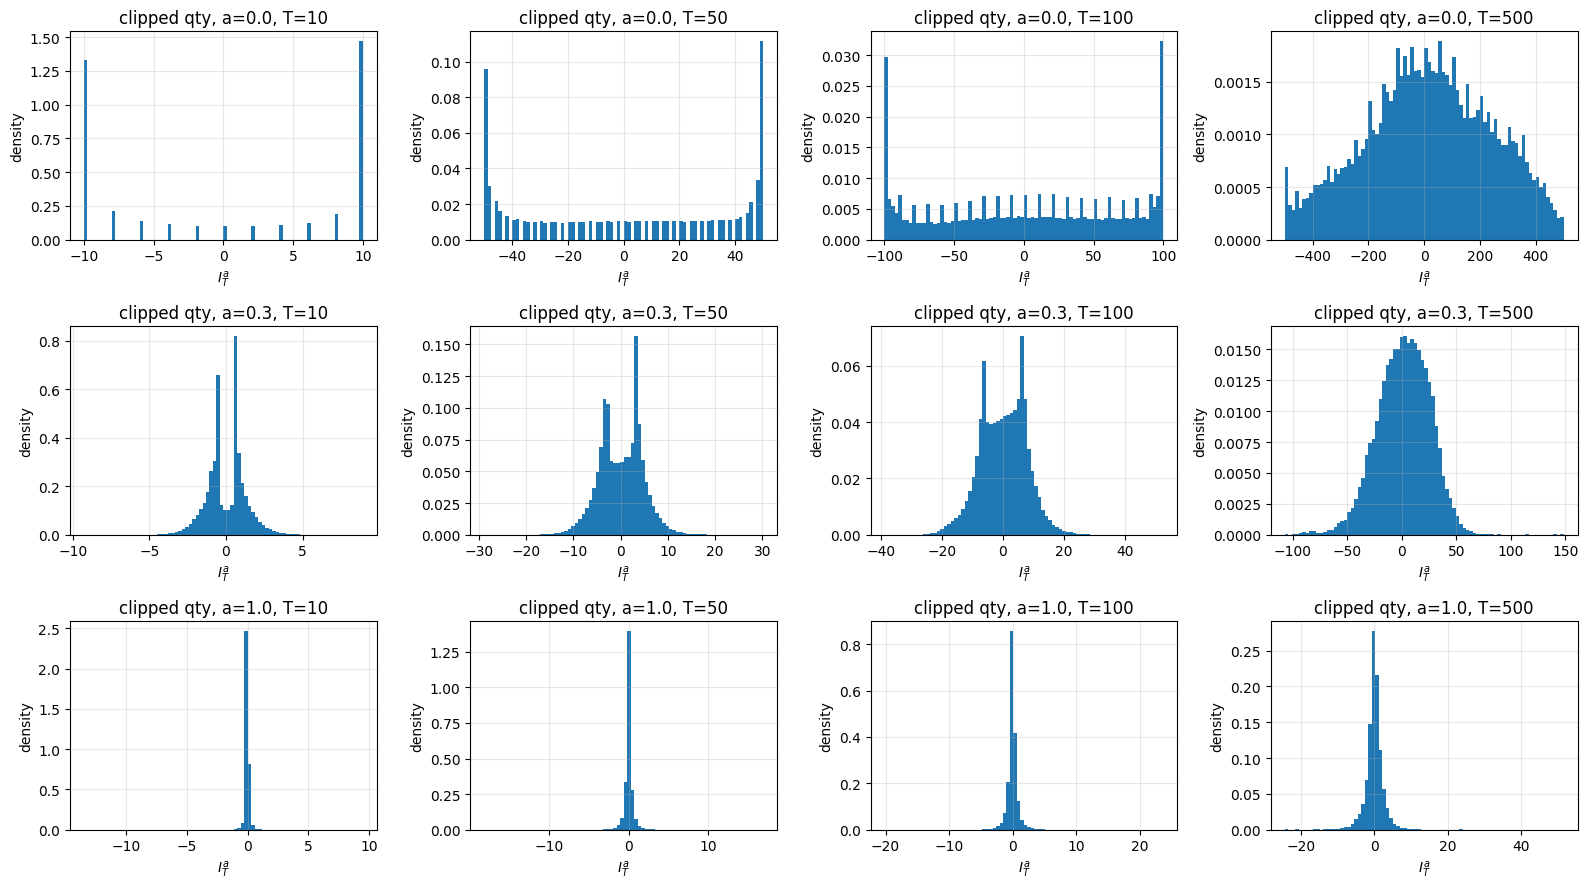

In [9]:
fig, axes = plt.subplots(len(selected_a_for_hist), len(selected_T_for_hist), figsize=(4 * len(selected_T_for_hist), 3 * len(selected_a_for_hist)), sharey=False)

for row, a in enumerate(selected_a_for_hist):
    for col, T in enumerate(selected_T_for_hist):
        ax = axes[row, col] if len(selected_a_for_hist) > 1 else axes[col]
        I = build_imbalance_series(sign, qty_clipped, T=T, a=a)
        I = I[np.isfinite(I)]
        ax.hist(I, bins=80, density=True)
        ax.set_title(f"clipped qty, a={a}, T={T}")
        ax.set_xlabel(r"$I_T^a$")
        ax.set_ylabel("density")
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


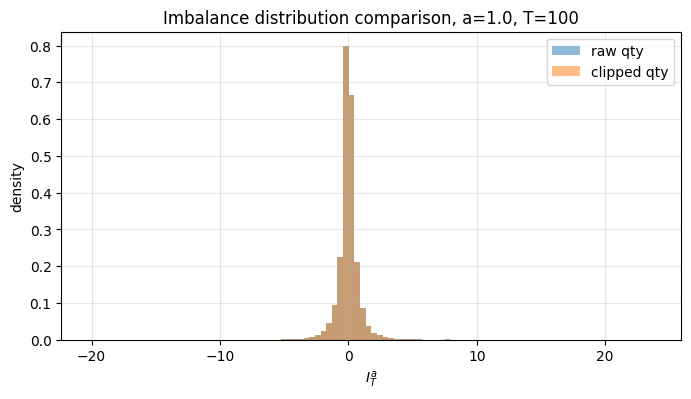

In [10]:
compare_T = 100
compare_a = 1.0

I_raw_compare = build_imbalance_series(sign, qty_raw, T=compare_T, a=compare_a)
I_clip_compare = build_imbalance_series(sign, qty_clipped, T=compare_T, a=compare_a)

plt.figure(figsize=(8, 4))
plt.hist(I_raw_compare[np.isfinite(I_raw_compare)], bins=100, density=True, alpha=0.5, label="raw qty")
plt.hist(I_clip_compare[np.isfinite(I_clip_compare)], bins=100, density=True, alpha=0.5, label="clipped qty")
plt.title(f"Imbalance distribution comparison, a={compare_a}, T={compare_T}")
plt.xlabel(r"$I_T^a$")
plt.ylabel("density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Even-Moment Scaling

We now estimate even raw moments of `I_T^a` across a grid of `T` and `a`.
This is the first direct paper-style scaling object in the notebook.


In [11]:
moment_rows = []

for qty_name, qty_values in qty_versions.items():
    for a in a_list:
        weighted = build_weighted_signed_flow(sign, qty_values, a)
        for T in T_list:
            I = rolling_window_sum(weighted, int(T))
            for moment_order in moment_orders:
                moment_rows.append({
                    "qty_version": qty_name,
                    "a": float(a),
                    "T": int(T),
                    "moment_order": int(moment_order),
                    "moment_value": even_raw_moment(I, order=moment_order),
                })

moment_df = pd.DataFrame(moment_rows)
display(moment_df.head())


,qty_version,a,T,moment_order,moment_value
0,raw,0.0,5,2,21.716789
1,raw,0.0,5,4,527.173538
2,raw,0.0,5,6,13051.425408
3,raw,0.0,10,2,79.993009
4,raw,0.0,10,4,7516.641563


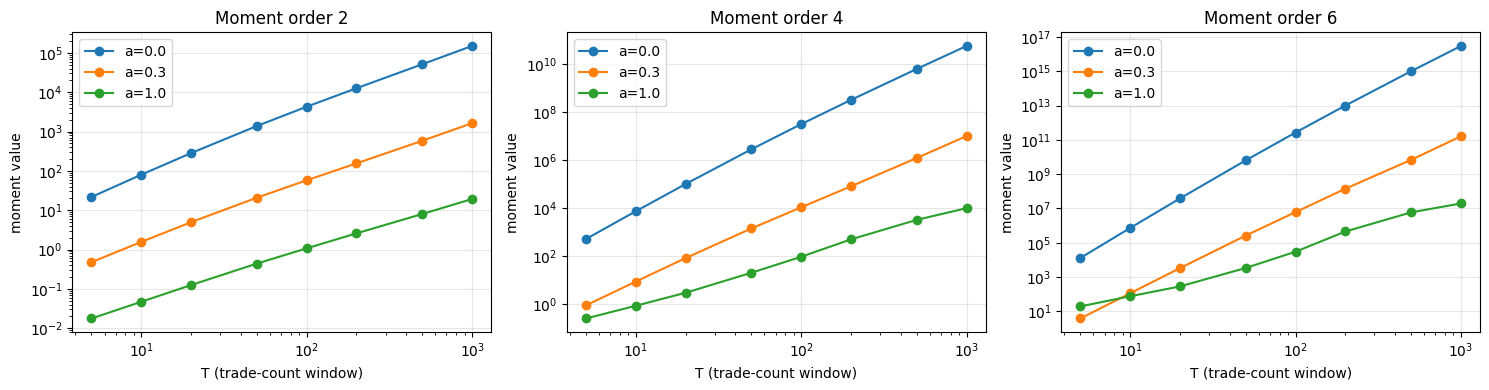

In [12]:
fig, axes = plt.subplots(1, len(moment_orders), figsize=(5 * len(moment_orders), 4), sharex=True)

for ax, moment_order in zip(np.atleast_1d(axes), moment_orders):
    for a in [0.0, 0.3, 1.0]:
        tmp = moment_df[
            (moment_df["qty_version"] == "clipped")
            & (moment_df["moment_order"] == moment_order)
            & (moment_df["a"] == a)
        ].sort_values("T")
        ax.plot(tmp["T"], tmp["moment_value"], marker="o", label=f"a={a}")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(f"Moment order {moment_order}")
    ax.set_xlabel("T (trade-count window)")
    ax.set_ylabel("moment value")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()


## Effective Scaling Exponents Versus `a`

For each even moment, we fit a simple log-log slope of the moment versus `T`.
The main question is whether the effective exponent changes materially as `a` changes.


In [13]:
slope_rows = []

for qty_name in moment_df["qty_version"].unique():
    for moment_order in moment_orders:
        for a in a_list:
            tmp = moment_df[
                (moment_df["qty_version"] == qty_name)
                & (moment_df["moment_order"] == moment_order)
                & (moment_df["a"] == a)
            ].sort_values("T")
            slope_rows.append({
                "qty_version": qty_name,
                "moment_order": int(moment_order),
                "a": float(a),
                "loglog_slope": fit_loglog_slope(tmp["T"].to_numpy(), tmp["moment_value"].to_numpy()),
            })

slope_df = pd.DataFrame(slope_rows)
display(slope_df)


,qty_version,moment_order,a,loglog_slope
0,raw,2,0.0,1.661011
1,raw,2,0.1,1.631333
2,raw,2,0.2,1.582857
3,raw,2,0.3,1.523830
4,raw,2,0.5,1.431300
5,raw,2,1.0,1.317389
6,raw,2,1.5,1.155675
7,raw,2,2.0,1.048558
8,raw,4,0.0,3.489323
9,raw,4,0.1,3.404928


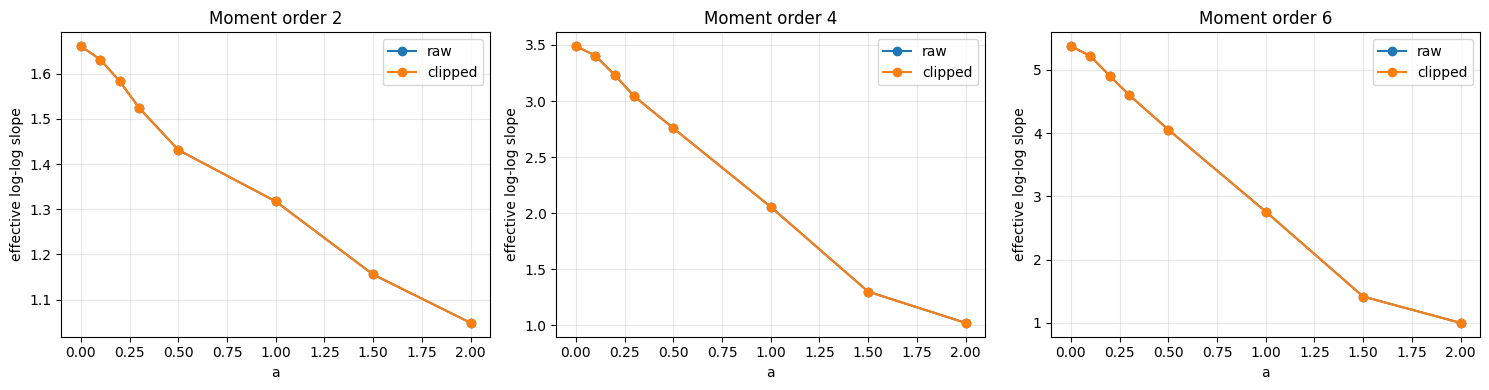

In [14]:
fig, axes = plt.subplots(1, len(moment_orders), figsize=(5 * len(moment_orders), 4), sharey=False)

for ax, moment_order in zip(np.atleast_1d(axes), moment_orders):
    for qty_name in ["raw", "clipped"]:
        tmp = slope_df[
            (slope_df["moment_order"] == moment_order)
            & (slope_df["qty_version"] == qty_name)
        ].sort_values("a")
        ax.plot(tmp["a"], tmp["loglog_slope"], marker="o", label=qty_name)
    ax.set_title(f"Moment order {moment_order}")
    ax.set_xlabel("a")
    ax.set_ylabel("effective log-log slope")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()


How to read the slope: for a fixed `a`, the fitted slope tells us how fast the chosen imbalance moment grows as the trade-count window `T` increases. When the slope moves closer to `1` as `a` increases, it means that heavily size-weighted imbalance behaves more like a weakly dependent aggregate and less like a strongly persistent sign-driven process. In practical terms, small `a` preserves the broad same-sign clustering in the tape, while large `a` puts more weight on the biggest trades and therefore reduces the persistence visible in the moment scaling.


## Short Takeaways

This notebook should leave us with four concrete answers:

- whether BTCUSDC imbalance moments grow faster than an independent-flow baseline,
- whether the effective scaling changes materially with `a`,
- whether clipping matters for larger `a`,
- which `(T, a)` regions are worth carrying into the return covariance / correlation notebook.

The next notebook should add trade-time price changes `Delta_T` and study:

- covariance `E[Delta_T * I_T^a]`,
- correlation `R_a(T)`,
- how those quantities vary jointly with `T` and `a`.
